In [1]:
import pandas as pd
import matplotlib.pyplot as plt
#کلاس مربوط به هر یک از پرداخت  قسط ها 
class Installment :
    def __init__ (self,period,pmt,intrest,principal,previous_balance,new_balance):
        self.period=period
        self.pmt=pmt
        self.total_payment=pmt+85000 #هزینه ی جانبی پرداخت شده در هر قسط 
        self.intrest=intrest
        self.principal=principal
        self.previous_balance=previous_balance
        self.new_balance=new_balance
        self.cumulative_intrest=0 #بهره تجمعی
        self.cumulative_principal=0 # اصل تجمعی
        
    def __str__ (self):
        return f'in period:{self.period},pmt={self.pmt},intrest={self.intrest},principal={self.principal},new balance={self.new_balance}\n'
    
    def as_dict(self): 
        return {'period':self.period,
                'previous balance':self.previous_balance,
                'Intrest':self.intrest,
                'Principal':self.principal,
                'new balance':self.new_balance,
                'Cumulative interest':self.cumulative_intrest,
                'Cumulative principal':self.cumulative_principal}



#کلاس مربوط به هر وام
class AmortizationSchedule :
    def __init__ (self,p,r,m,n):
        self.p=p-p*0.015      #کسر یک و نیم درصد کارمزد در ابتدای تشکیل پرونده
        self.r=r
        self.m=m #تعداد پرداخت در هر سال
        self.n=n #تعداد تمامی پرداخت ها
        self.i=r/m
        self.pmt=p*((self.i*(1+self.i)**n)/((1+self.i)**n-1)) # فرمول محاسبه قسط سالیانه بر حسب مقدار اولیه
        self.schedule=[]

    def create_payment (self,t,balance):
        intrest_t=balance*self.i
        principal_t=self.pmt-intrest_t
        balence_t=balance-principal_t
        return Installment(period=t,pmt=self.pmt,intrest=intrest_t,principal=principal_t,previous_balance=balance,new_balance=balence_t)
    
    
    def create_schedule(self,x):  #در حالت نبود نرخ بهره ی شناور x=n
        b=self.p

        for i in range(1,x+1):
            new_payment=self.create_payment(i,b)
            if i==1:
                new_payment.cumulative_intrest+=new_payment.intrest
                new_payment.cumulative_principal+=new_payment.principal
            else:
                new_payment.cumulative_intrest=self.schedule[i-2].cumulative_intrest+new_payment.intrest #محاسبه بهره تجمعی
                new_payment.cumulative_principal=self.schedule[i-2].cumulative_principal+new_payment.principal #محاسبه اصل تجمعی
            self.schedule.append(new_payment)
            b = new_payment.new_balance

    


    def as_dataframe(self):
        return pd.DataFrame([p.as_dict() for p in self.schedule],columns=[
            'period','previous balance','Intrest','Principal','new balance','Cumulative interest','Cumulative principal'])
    



original scenario:

In [2]:

loan=AmortizationSchedule(780000000,0.21,12,42)
loan.create_schedule(42)
df=loan.as_dataframe()
df["total payment"] = loan.schedule[0].total_payment
df

,period,previous balance,Intrest,Principal,new balance,Cumulative interest,Cumulative principal,total payment
0,1,7.683000e+08,1.344525e+07,1.293480e+07,7.553652e+08,1.344525e+07,1.293480e+07,2.646505e+07
1,2,7.553652e+08,1.321889e+07,1.316116e+07,7.422040e+08,2.666414e+07,2.609595e+07,2.646505e+07
2,3,7.422040e+08,1.298857e+07,1.339148e+07,7.288126e+08,3.965271e+07,3.948743e+07,2.646505e+07
3,4,7.288126e+08,1.275422e+07,1.362583e+07,7.151867e+08,5.240693e+07,5.311326e+07,2.646505e+07
4,5,7.151867e+08,1.251577e+07,1.386428e+07,7.013225e+08,6.492270e+07,6.697754e+07,2.646505e+07
5,6,7.013225e+08,1.227314e+07,1.410690e+07,6.872156e+08,7.719584e+07,8.108444e+07,2.646505e+07
6,7,6.872156e+08,1.202627e+07,1.435378e+07,6.728618e+08,8.922212e+07,9.543822e+07,2.646505e+07
7,8,6.728618e+08,1.177508e+07,1.460497e+07,6.582568e+08,1.009972e+08,1.100432e+08,2.646505e+07
8,9,6.582568e+08,1.151949e+07,1.486055e+07,6.433963e+08,1.125167e+08,1.249037e+08,2.646505e+07
9,10,6.433963e+08,1.125943e+07,1.512061e+07,6.282757e+08,1.237761e+08,1.400243e+08,2.646505e+07


In [ ]:
plt.plot(df['period'],df['Intrest'],label="Interest",color='orange')
plt.plot(df['period'],df['Principal'],label="Principal",color='green')
plt.show()

Period extention:

In [ ]:
loan=AmortizationSchedule(780000000,0.21,12,60) #پرداخت در 60 ماه انجام می شود
loan.create_schedule(60)
df=loan.as_dataframe()
df["total payment"] = loan.schedule[0].total_payment
df

In [ ]:
plt.plot(df['period'],df['Intrest'],label="Interest",color='blue')
plt.plot(df['period'],df['Principal'],label="Principal",color='yellow')
plt.show()

Floating Rate :

In [ ]:
loan=AmortizationSchedule(780000000,0.21,12,42)
loan.create_schedule(18) 
new_p=loan.schedule[17].new_balance 
new_loan=AmortizationSchedule(new_p,0.28,12,24)
new_loan.create_schedule(24)
loan.schedule.extend(new_loan.schedule)
df=loan.as_dataframe()
df["total payment"] = loan.schedule[0].total_payment
df

In [ ]:
plt.plot(df.index.tolist(),df['Intrest'],label="Interest",color='blue')  
plt.plot(df.index.tolist(),df['Principal'],label="Principal",color='red')
# برای اینکه نمودار به صورت خط خطی در نیاد به جای دوره ی زمانی از ایندکس ها استفاده کردیم(✿◡‿◡)
plt.show()

Prepayment :

In [ ]:
loan=AmortizationSchedule(780000000,0.21,12,42)
loan.create_schedule(6)

n=7  #شمارنده ای که تعریف کردیم
while loan.schedule[-1].new_balance>0:    
    intrest=loan.schedule[-1].previous_balance*loan.i
    principal=loan.schedule[-1].previous_balance - intrest
    principal+=6500000
    new_balance=loan.schedule[-1].previous_balance - principal
    new_payment=Installment(period=n,pmt=loan.schedule[-1].total_payment,intrest=intrest,principal=principal,
                            previous_balance=loan.schedule[-1].new_balance,new_balance=new_balance)
    new_payment.cumulative_intrest=loan.schedule[-1].cumulative_intrest+new_payment.intrest
    new_payment.cumulative_principal=loan.schedule[-1].cumulative_principal+new_payment.principal
    loan.schedule.append(new_payment)
    n+=1
    if loan.schedule[-1].new_balance==0: 
        loan.schedule[-1].new_balance=0

df=loan.as_dataframe()
df["total payment"] = loan.schedule[0].total_payment
df

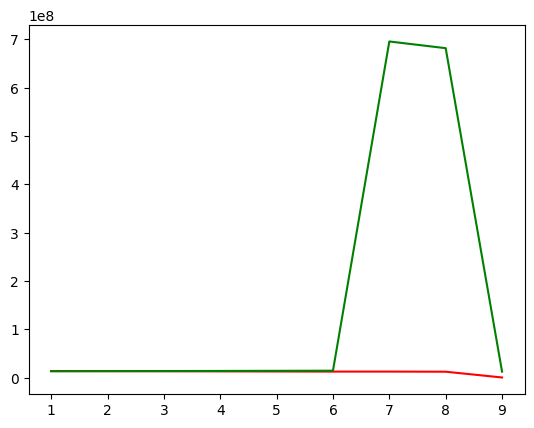

In [41]:
plt.plot(df['period'],df['Intrest'],label="Interest",color='red')
plt.plot(df['period'],df['Principal'],label="Principal",color='green')
plt.show()
#(≧﹏ ≦) I tried but...